# Chi-Square Tests

## Overview

Tests for categorical data comparing observed to expected frequencies.

| Test | Question | scipy |
|---|---|---|
| Goodness-of-fit | Does distribution match expected? | `chisquare` |
| Independence | Are two categorical variables associated? | `chi2_contingency` |
| Fisher's exact | Independence for small expected counts | `fisher_exact` |

Use Fisher's exact test when any expected cell count is below 5. Effect size: Cramer's V.

---

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)
n = 200
df = pd.DataFrame({
    "catchment":     rng.choice(["North","South","East","West"], n),
    "treatment":     rng.choice(["control","restored"], n),
    "richness_class":rng.choice(["low","medium","high"], n, p=[0.3,0.4,0.3])
})

---
## Goodness-of-Fit Test

In [2]:
obs = df["catchment"].value_counts().sort_index().values
exp = np.full(4, n/4)
chi2, p = stats.chisquare(obs, f_exp=exp)
print(f"GOF test (equal sampling?): chi2={chi2:.3f}, p={p:.4f}")
print(f"Observed: {dict(zip(sorted(df.catchment.unique()), obs))}")
print(f"Expected: {n//4} each")

GOF test (equal sampling?): chi2=0.520, p=0.9145
Observed: {'East': np.int64(50), 'North': np.int64(46), 'South': np.int64(53), 'West': np.int64(51)}
Expected: 50 each


---
## Test of Independence

Contingency table:
richness_class  high  low  medium
treatment                        
control           32   36      40
restored          27   25      40

Chi2=1.135, dof=2, p=0.5671
Min expected count: 27.1  (>5 is fine)
Cramer's V = 0.075  (small<0.1, medium<0.3, large>=0.3)


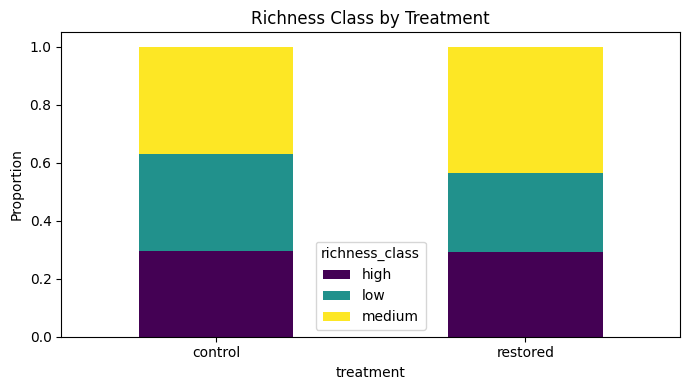

In [3]:
ct = pd.crosstab(df["treatment"], df["richness_class"])
print("Contingency table:")
print(ct)
chi2, p, dof, exp = stats.chi2_contingency(ct, correction=False)
print(f"\nChi2={chi2:.3f}, dof={dof}, p={p:.4f}")
print(f"Min expected count: {exp.min():.1f}  (>5 is fine)")
V = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print(f"Cramer's V = {V:.3f}  (small<0.1, medium<0.3, large>=0.3)")
ct.div(ct.sum(axis=1),axis=0).plot(kind="bar",stacked=True,colormap="viridis",figsize=(7,4))
plt.title("Richness Class by Treatment"); plt.ylabel("Proportion")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

---
## Fisher's Exact Test

In [4]:
small = np.array([[4,12],[9,6]])
or_, p_f = stats.fisher_exact(small, alternative="two-sided")
print(f"Fisher's exact: OR={or_:.3f}, p={p_f:.4f}")
_,p_c,_,exp_s = stats.chi2_contingency(small)
print(f"Chi2 (comparison): p={p_c:.4f}, min expected={exp_s.min():.1f}")
print("Min expected < 5 -> Fisher's exact is appropriate here")

Fisher's exact: OR=0.222, p=0.0732
Chi2 (comparison): p=0.1075, min expected=6.3
Min expected < 5 -> Fisher's exact is appropriate here


---

## Common Pitfalls

**1. Using chi-square when expected cell counts are below 5**  
The chi-square approximation is unreliable for small expected counts. Use Fisher's exact test for 2x2 tables, or collapse categories to increase expected counts.

**2. Not reporting effect size**  
A significant chi-square p-value says nothing about strength of association. Always report Cramer's V.

**3. Passing proportions instead of counts**  
Chi-square requires raw counts. Passing proportions produces incorrect test statistics.

**4. Using Yates' continuity correction by default**  
`chi2_contingency` applies Yates' correction by default. This over-corrects for large samples. Use `correction=False` for expected counts > 5.

**5. Confusing goodness-of-fit with test of independence**  
GOF tests one variable against a theoretical distribution. Independence tests the association between two variables. Different null hypotheses and degrees of freedom.


---
*python_methods_library - Samantha McGarrigle*